In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('/content/Diamonds - Regression.csv')

In [ ]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
print(df['cut'].value_counts(),'\n')
print(df['color'].value_counts(),'\n')
print(df['clarity'].value_counts(),'\n')

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64 

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64 

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64 



In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.columns = ['id',	'carat','cut',	'color',	'clarity',	'depth',	'table',	'price',	'x',	'y',	'z']

In [ ]:
df.columns

Index(['id', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price',
       'x', 'y', 'z'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
id,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
cut_mapping = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_mapping = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_mapping = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

df['cut_encoded'] = df['cut'].map(cut_mapping)
df['color_encoded'] = df['color'].map(color_mapping)
df['clarity_encoded'] = df['clarity'].map(clarity_mapping)

Features shape: (53940, 9)
Target shape: (53940,)


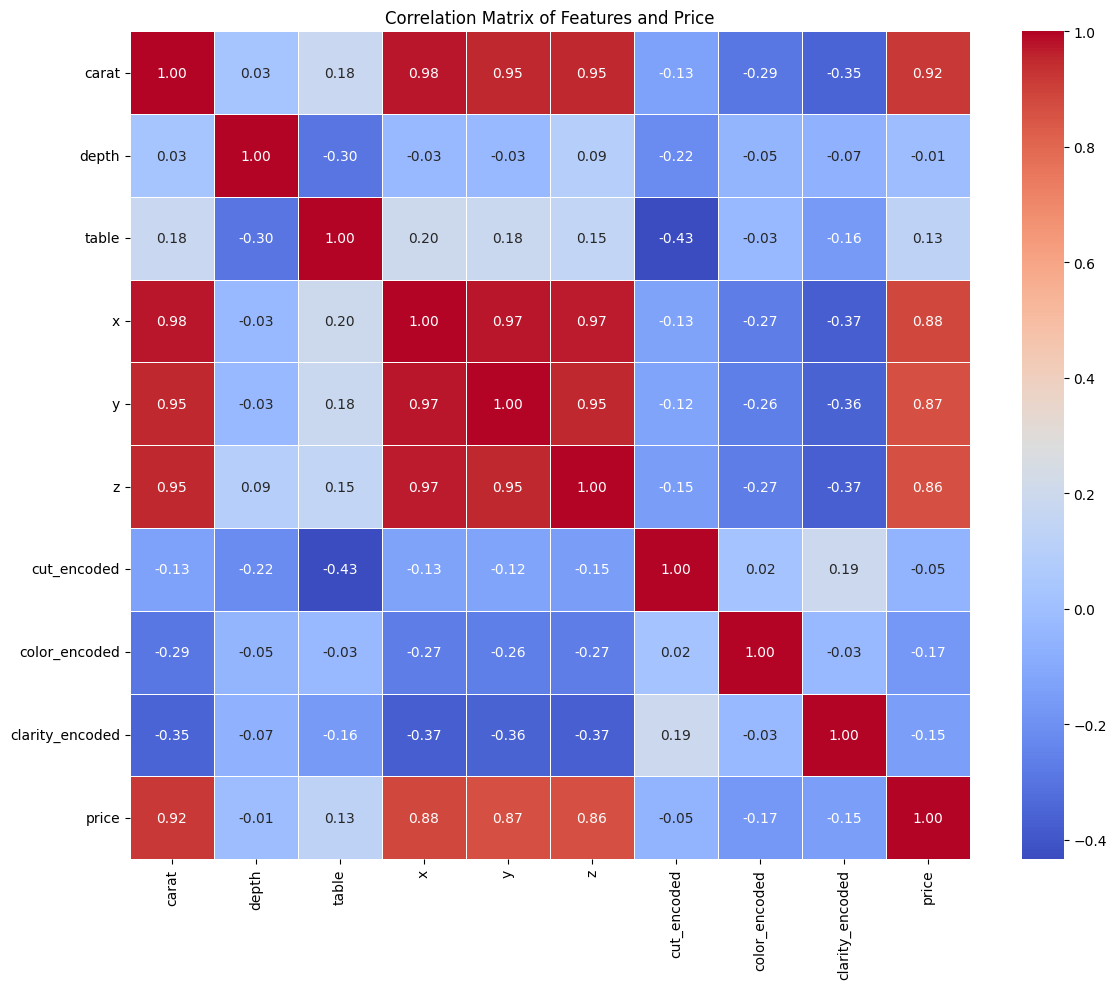

In [ ]:
feature_columns = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_encoded', 'color_encoded', 'clarity_encoded']
X = df[feature_columns]
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

plt.figure(figsize=(12, 10))
correlation_matrix = X.copy()
correlation_matrix['price'] = y
sns.heatmap(correlation_matrix.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features and Price')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svr_base = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_base.fit(X_train_scaled, y_train)

y_pred_svr_base = svr_base.predict(X_test_scaled)

print("=== Base SVR Model Performance ===")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_svr_base):.2f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred_svr_base):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_svr_base)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_svr_base):.4f}")

=== Base SVR Model Performance ===
MAE: $1268.50
MSE: $7400101.31
RMSE: $2720.31
R² Score: 0.5345


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Multiple Linear Regression Performance ===")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}")

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\nFeature Coefficients (Linear Regression):")
print(feature_importance)

=== Multiple Linear Regression Performance ===
MAE: $805.27
MSE: $1499636.69
RMSE: $1224.60
R² Score: 0.9057

Feature Coefficients (Linear Regression):
           Feature  Coefficient
0            carat  5101.623213
3                x  -978.246637
8  clarity_encoded   827.354241
7    color_encoded   550.173002
6      cut_encoded   138.118642
1            depth  -115.807528
2            table   -60.365910
4                y    26.273673
5                z   -11.121103


In [ ]:
knn_base = KNeighborsRegressor(n_neighbors=5, metric='euclidean')
knn_base.fit(X_train_scaled, y_train)

y_pred_knn_base = knn_base.predict(X_test_scaled)

print("=== Base KNN Regressor (k=5) Performance ===")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_knn_base):.2f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred_knn_base):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_knn_base)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_knn_base):.4f}")

=== Base KNN Regressor (k=5) Performance ===
MAE: $374.34
MSE: $507844.83
RMSE: $712.63
R² Score: 0.9681


In [ ]:
param_grid_svr = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}
svr_grid = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

svr_grid.fit(X_train_scaled, y_train)

print(f"\nBest SVR Parameters: {svr_grid.best_params_}")
print(f"Best Cross-Validation R² Score: {svr_grid.best_score_:.4f}")

best_svr = svr_grid.best_estimator_
y_pred_svr_best = best_svr.predict(X_test_scaled)

print(f"MAE: ${mean_absolute_error(y_test, y_pred_svr_best):.2f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred_svr_best):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_svr_best)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_svr_best):.4f}")

=== SVR Hyperparameter Tuning ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_scaled, y_train)

print(f"\nBest KNN Parameters: {knn_grid.best_params_}")
print(f"Best Cross-Validation R² Score: {knn_grid.best_score_:.4f}")

best_knn = knn_grid.best_estimator_
y_pred_knn_best = best_knn.predict(X_test_scaled)

print(f"MAE: ${mean_absolute_error(y_test, y_pred_knn_best):.2f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred_knn_best):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_knn_best)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_knn_best):.4f}")

In [ ]:
results = {
    'Model': ['Linear Regression', 'Base SVR (RBF)', 'Tuned SVR', 'Base KNN (k=5)', 'Tuned KNN'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_svr_base),
        mean_absolute_error(y_test, y_pred_svr_best),
        mean_absolute_error(y_test, y_pred_knn_base),
        mean_absolute_error(y_test, y_pred_knn_best)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr_base)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn_base)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn_best))
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_svr_base),
        r2_score(y_test, y_pred_svr_best),
        r2_score(y_test, y_pred_knn_base),
        r2_score(y_test, y_pred_knn_best)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))